In [1]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install jinja2

# Importing libraries for KMeans and Heirarchical Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

#read csv in
model_data = pd.read_csv('model_data.csv')
storm_df = pd.read_csv('storm_df.csv')


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from modeling_fcns import *

In [3]:
#Run cluster analysis on model_data

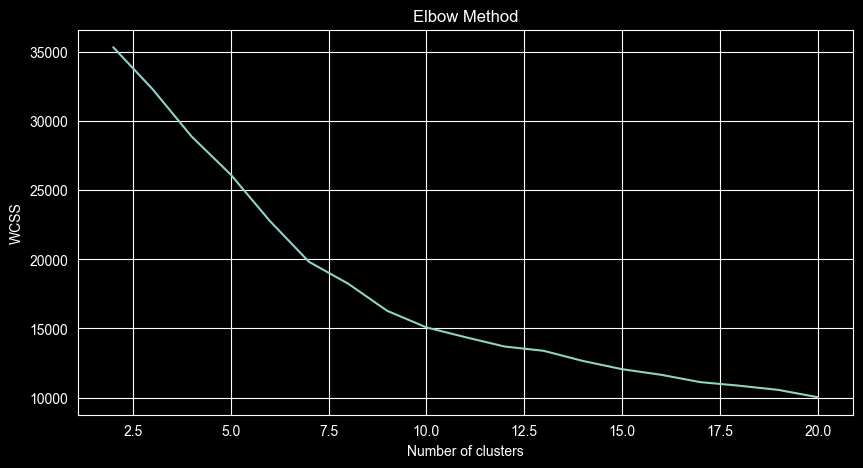

[35366.998455821835, 32343.12862472389, 28907.704356973696, 26149.780144638033, 22785.87261497747, 19828.55830592478, 18245.832108708553, 16276.726590585706, 15077.131286648431, 14367.959597629648, 13691.898323571822, 13381.192251828517, 12647.839790054171, 12051.00440663626, 11644.842194526263, 11113.842393271989, 10853.92709321314, 10548.182581632202, 10021.634078761568]


In [4]:
#k means clustering - wcss plot (cluster compactness)

wcss = []
for k in range(2, 21):
    result = cluster(model_data,k,plot=False)
    wcss.append(result['model'].inertia_)

# Plotting the elbow plot
plt.figure(figsize=(10, 5))
plt.plot(range(2, 21), wcss)

plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

print(wcss)

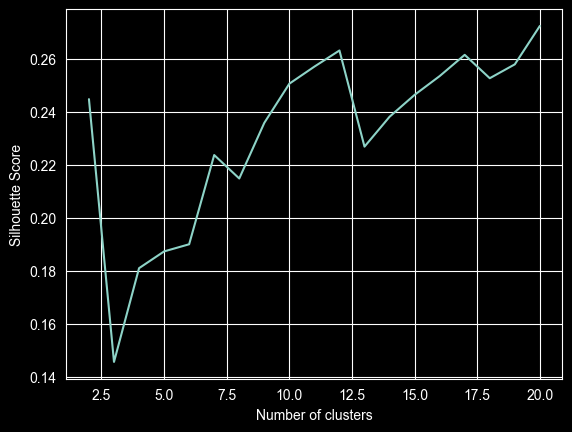

In [5]:
#choose optimal k
scores = []

for k in range(2,21):
    model = cluster(model_data,k,plot=False)
    scores.append(model['silhouette'])

plt.plot(range(2, 21), scores)

plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()




In [6]:
result = cluster(model_data, 10, plot = True)

print(result)

{'data':       Unnamed: 0                   md_key  USA_SSHS  STORM_LOC_BIN  CD2LAND  \
0              0     2022-06-27-Pensacola        -3              1        2   
1              1     2022-06-28-Pensacola        -3              1        2   
2              2     2022-06-29-Pensacola        -3              1        1   
3              3     2022-06-30-Pensacola        -3              1        1   
4              4     2022-07-01-Pensacola         0              1        1   
...          ...                      ...       ...            ...      ...   
3199        3199  2025-10-28-Jacksonville         5              1        1   
3200        3200  2025-10-29-Jacksonville         2              1        1   
3201        3201  2025-10-30-Jacksonville         2              1        2   
3202        3202  2025-10-31-Jacksonville        -4              1        2   
3203        3203  2025-11-01-Jacksonville        -4              1        2   

      CD2LANDFALL  CD2METRO  INBOUND  CD2O

In [7]:
result['centroids']

,Unnamed: 0,USA_SSHS,STORM_LOC_BIN,CD2LAND,CD2LANDFALL,CD2METRO,INBOUND,CD2OIL,OIL_THT,STORM_LEN,month_no,buy_avg,buy_day,cluster
0,-0.017096,0.525066,0.328647,0.608534,0.558826,0.097220,-0.707107,0.075165,-0.230769,0.052447,-0.206503,-0.337135,-0.140473,0
1,0.125231,-0.001980,0.450225,0.119862,0.197258,0.097220,0.235702,0.075165,-0.230769,-0.657460,0.587362,2.966170,-0.140473,1
2,-0.000456,0.270001,-2.221111,-0.772332,-0.930084,0.097220,-0.146472,0.075165,4.333333,-0.525018,0.028503,0.252741,-0.140473,2
3,0.092982,-0.150720,-2.221111,-0.472168,-0.113829,0.097220,0.117851,-13.304135,2.051282,-0.179442,0.959718,-0.337135,-0.140473,3
4,-0.041356,0.449207,0.450225,0.633699,0.538120,0.097220,1.414214,0.075165,-0.230769,-0.633786,-0.083079,-0.337135,-0.140473,4
5,-0.033275,-0.323496,0.450225,-1.578036,-1.329527,0.097220,0.033311,0.075165,-0.230769,0.018201,-0.026024,-0.337135,-0.140473,5
6,0.250690,0.763724,-1.330665,-1.578036,-1.329527,-10.285913,-0.424264,0.075165,0.834188,-0.202927,0.240435,0.433636,-0.140473,6
7,0.465378,0.005447,0.191709,0.241295,-0.048469,0.097220,-0.022810,0.075165,0.210918,0.089508,0.031610,0.781726,7.118807,7
8,-0.017088,0.276757,-2.221111,-1.182560,-1.136304,0.097220,-0.313749,0.075165,-0.230769,-0.282872,0.007025,0.483222,-0.140473,8
9,-0.002573,-1.300387,0.361015,0.596769,0.565067,0.097220,-0.565423,0.075165,-0.230769,1.223167,0.150691,-0.331006,-0.140473,9


In [8]:
storm_df = storm_df.drop(['Unnamed: 0','start_month','end_month'], axis=1)
storm_df.head()

,NAME,MAX CAT,STORM DURATION,gas_pct_change
0,BERYL,5,13,2.738516
1,BONNIE,3,13,-5.382944
2,DANIELLE,1,15,-4.746807
3,DEBBY,1,8,-1.423973
4,DON,1,14,-0.143964


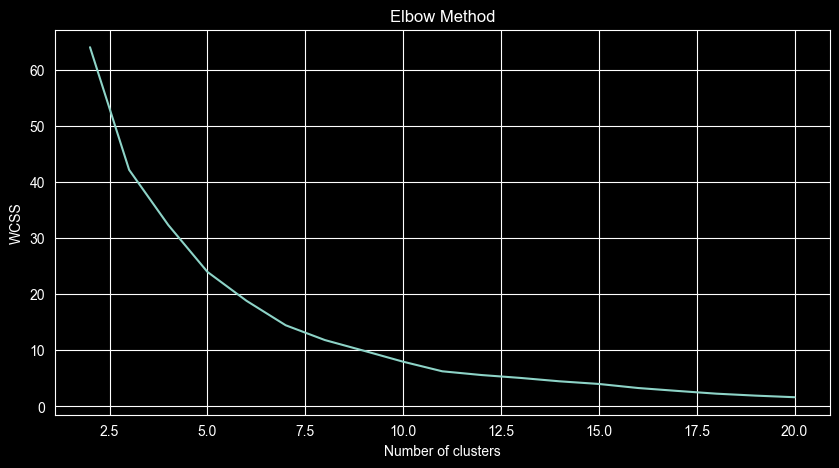

[64.05586385020207, 42.185515611593885, 32.346150430305116, 23.99016820149539, 18.82685178040037, 14.471773742884976, 11.83691818150935, 9.921716142480426, 7.975642708400474, 6.264868169084837, 5.5988300027412885, 5.08053972088707, 4.477099009414361, 4.007220933746999, 3.2848422526270245, 2.7672013288494792, 2.2746780201850916, 1.92678317195648, 1.641079315934244]


In [9]:
#Run cluster analysis on storm_df

wcss = []
for k in range(2, 21):
    result = cluster(storm_df,k,plot=False)
    wcss.append(result['model'].inertia_)

# Plotting the elbow plot
plt.figure(figsize=(10, 5))
plt.plot(range(2, 21), wcss)

plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

print(wcss)

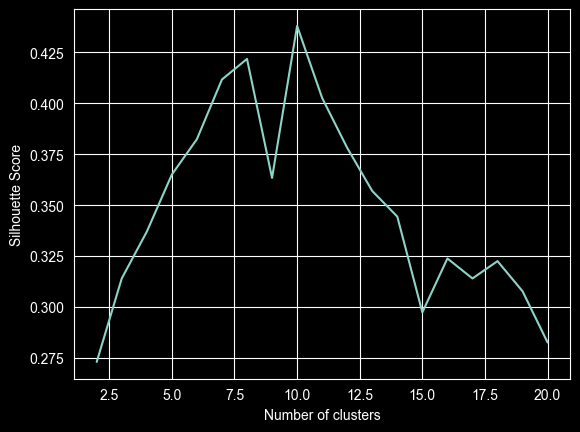

[0.27303276448516306, 0.31402224894169345, 0.3369938215042936, 0.3650287071098074, 0.3824055658698689, 0.41170986205580623, 0.4218106725365314, 0.36337790760187183, 0.43801241275186154, 0.4026306111514076, 0.37813280497707885, 0.35695814900911926, 0.34438778658891334, 0.29738186510991477, 0.32383209233944993, 0.31401200553374653, 0.3225227757018692, 0.30772404321058205, 0.28256482840074626]


In [10]:
scores = []

for k in range(2,21):
    model = cluster(storm_df,k,plot=False)
    scores.append(model['silhouette'])

plt.plot(range(2, 21), scores)

plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

print(scores)


In [15]:
#8 clusters gets highest silhouette score and is transition point in elbow method

result2 = cluster(storm_df, 8, plot = True)

print(result2)

{'data':          NAME  MAX CAT  STORM DURATION  gas_pct_change  cluster
0       BERYL        5              13        2.738516        2
1      BONNIE        3              13       -5.382944        5
2    DANIELLE        1              15       -4.746807        5
3       DEBBY        1               8       -1.423973        1
4         DON        1              14       -0.143964        1
5        EARL        2              12       -4.140102        5
6        ERIN        5              16        3.148024        2
7     ERNESTO        2               9       -0.478469        1
8       FIONA        4              13       -1.809806        3
9    FRANCINE        2               5       -1.010739        7
10   FRANKLIN        4              21       -0.216816        6
11  GABRIELLE        4              11       -5.872965        5
12     HELENE        4               5        2.113585        0
13   HUMBERTO        5               7        1.057851        0
14        IAN        5         

In [21]:
#inverse scale:
centroids_scaled = result2['centroids'].copy()
features = ['MAX CAT', 'STORM DURATION','gas_pct_change']

centroids_numeric = centroids_scaled[features]

centroids_original = pd.DataFrame(result2['scaler'].inverse_transform(centroids_numeric),columns = features)

centroids_original['cluster']= centroids_scaled['cluster']

centroids_original = centroids_original.rename(columns = {'gas_pct_change':'PERCENT CHANGE GAS', 'cluster':'CLUSTER'})
#centroids = result2['centroids']
centroids_original = centroids_original.sort_values('PERCENT CHANGE GAS', ascending = True)

centroids_original.style.background_gradient(cmap='coolwarm')


,MAX CAT,STORM DURATION,PERCENT CHANGE GAS,CLUSTER
5,2.500000,12.750000,-5.035705,5
3,4.250000,12.000000,-0.991542,3
1,1.555556,10.444444,-0.302761,1
6,4.000000,21.000000,-0.216816,6
7,1.333333,4.000000,-0.045391,7
0,4.400000,6.600000,0.805943,0
4,1.000000,5.000000,2.847428,4
2,5.000000,13.333333,3.104771,2


In [18]:
#look at cluster proportion

cluster_counts = result2['data']['cluster'].value_counts()
cluster_proportion = cluster_counts/len(result2['data']['cluster'])

cluster_summary = result2['centroids'].copy()
cluster_summary['size'] = cluster_counts.values
cluster_summary['proportion']=cluster_proportion.values
cluster_summary

,MAX CAT,STORM DURATION,gas_pct_change,cluster,size,proportion
0,1.027204,-0.802440,0.413734,0,9,0.28125
1,-0.777784,0.157851,-0.058391,1,5,0.15625
2,1.407943,0.879457,1.392654,2,4,0.12500
3,0.932019,0.546408,-0.351697,3,4,0.12500
4,-1.130321,-1.202098,1.283068,4,3,0.09375
5,-0.178472,0.733748,-2.073840,5,3,0.09375
6,0.773377,2.794488,-0.021792,6,3,0.09375
7,-0.918799,-1.451885,0.051206,7,1,0.03125
